## Exchange Rate Dynamics: INR/USD (Jan 2013 - Dec 2025)

### Structure:-
____________________________________________________________________

- Part 1: Environment Setup & Library Imports
- Part 2: Data Import & Initial Inspection
- Part 3: Missing Value Imputation
- Part 4: Data Manipulation (INR -> USD conversion)
- Part 5: Feature Engineering (CAB/GDP, INT_DIFF, logs, etc.)
- Part 6: Exploratory Data Analysis
- Part 7: Unit Root Tests (ADF + KPSS + PP)
- Part 8: ARDL Bounds Test
- Part 9: Partitioned VECM (Robustness Check)
- Part 10: Interpretation
- Part 11: Conclusion
____________________________________________________________________

### PART 1: ENVIRONMENT SETUP & LIBRARY IMPORTS

In [1]:
import pandas as pd
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from statsmodels.tsa.stattools import adfuller, kpss, grangercausalitytests
from arch.unitroot import PhillipsPerron
from statsmodels.tsa.ardl import UECM
from statsmodels.tsa.vector_ar.vecm import select_order
from statsmodels.tsa.vector_ar.var_model import VAR
from statsmodels.tsa.vector_ar.vecm import coint_johansen, VECM
from statsmodels.regression.linear_model import OLS
from statsmodels.tools import add_constant
from scipy import stats

#-- Global plot style ------------------------------------------
# Setting these once means every chart produced inherits them.
# figure.dpi=300 -> publication quality (journals require >= 300 DPI)
# font.family='serif' -> matches the Times New Roman convention in academic economics papers.
plt.rcParams.update({
    'figure.dpi'     : 300,
    'font.family'    : 'serif',
    'font.size'      : 10,
    'axes.labelsize' : 11,
    'axes.titlesize' : 12,
    'legend.fontsize': 9,
})

print("="*65)
print("  RESEARCH PIPELINE STARTED")
print("="*65)

  RESEARCH PIPELINE STARTED


### PART 2: DATA IMPORT AND INITIAL INSPECTION

In [2]:
print("\n" + "-" * 65)
print("  PART 2: DATA IMPORT")
print("-" * 65)

df_raw = pd.read_excel('Sub_Sample.xlsx', parse_dates=['Date'])

df_raw = df_raw.set_index('Date')

df_raw.index = df_raw.index + pd.offsets.MonthEnd(0)    # This ensures all monthly series align on the same calendar day.

print(f"\n Rows loaded  : {df_raw.shape[0]}")
print(f" Columns loaded : {df_raw.shape[1]}")
print(f" Date range     : {df_raw.index[0].date()} -> {df_raw.index[-1].date()}")

print("\n Column inventory:")
for col in df_raw.columns:
    print(f" {col:<40} dtype: {df_raw[col].dtype}")

print("\n Missing values before imputation:")
miss = df_raw.isnull().sum()
for col, n in miss[miss > 0].items():
    dates = df_raw[df_raw[col].isna()].index.date.tolist()
    print(f" {col:<40} {n} missing at {dates}")

print("\n Sample values - first 5 rows:")
print(df_raw[['INR_USD', '3M_ForwardPremium_IND(%)', '91D_TBillYield_IND(%)', 'FPI_Equity_IND($M)', 'VIX_US', 'BrentCrudeOilPrice($)']].head(5).to_string())


-----------------------------------------------------------------
  PART 2: DATA IMPORT
-----------------------------------------------------------------

 Rows loaded  : 158
 Columns loaded : 23
 Date range     : 2013-01-31 -> 2026-02-28

 Column inventory:
 INR_USD                                  dtype: float64
 3M_ForwardPremium_IND(%)                 dtype: float64
 RepoRate_IND(%)                          dtype: float64
 FCA_IND($M)                              dtype: float64
 CPI_IND                                  dtype: float64
 BroadMoney_M3_IND(₹Cr)                   dtype: float64
 NGDP_CP_IND(₹Cr)                         dtype: float64
 CAB_IND($M)                              dtype: float64
 TradeBalance_IND($M)                     dtype: float64
 FPI_Equity_IND($M)                       dtype: int64
 FPI_Debt_IND($M)                         dtype: int64
 Net_FDI_IND($M)                          dtype: float64
 VIX_IND                                  dtype: float64
 RE

### PART 3: MISSING VALUE IMPUTATION

- With only 158 monthly observations, dropping even one row loses an entire month of information across all variables - not just the one with the missing value. Since the missing values are isolated (1-2 observations each), imputation is far superior to deletion.

- Linear Interpolation: For a single gap between two known values A and B, linear interpolation estimates the missing values as the midpoint. This is the most accurate unbiased estimate for a smooth series.

- Forward Fill: Replaces missing values in a sequence with the most recent known observation, avoids speculative extrapolation. (Though, these rows are trimmed from the analytical sample anyway.)*

In [3]:
print("\n" + "-" * 65)
print("  PART 3: MISSING VALUE IMPUTATION")
print("-" * 65)

df = df_raw.copy()    # Working on a copy to preserve raw data

#-- 3A. BroadMoney M3, November 2025 --------------------------
# Interpolate (method='linear') fills the NaN by drawing a straight line between the nearest non-null neighbours.
df['BroadMoney_M3_IND(₹Cr)'] = df['BroadMoney_M3_IND(₹Cr)'].interpolate(method='linear')
print("\n BroadMoney M3 (Nov-2025): linear interpolation applied")

#-- 3B. CPI US, October 2025 -------------------------------------
df['CPI_US'] = df['CPI_US'].interpolate(method='linear')
print("\n CPI US (Oct-2025): linear interpolation applied")

#-- 3C. NGDP and CAB, Jan & Feb 2026 -----------------------------
# ffill() = forward fill = carry last valid value forward
df['NGDP_CP_IND(₹Cr)'] = df['NGDP_CP_IND(₹Cr)'].ffill()
df['CAB_IND($M)'] = df['CAB_IND($M)'].ffill()
print("\n  NGDP (Jan,Feb-2026): forward fill applied")
print("  CAB (Jan,Feb-2026): forward fill applied")

#-- 3D. Verify zero missing values ------------------------------
remaining = df.isnull().sum().sum()
print(f"\n Missing values after imputation: {remaining} <- should be 0")

#-- 3E. Trim to clean analytical window -------------------------
# Jan and Feb 2026 are forward-filled estimates and represent incomplete months. My analytical sample is Jan 2013 - Dec 2025.
# 156 monthly observations - adequate for VAR/VECM estimation.
df = df[:'2025-12-31']
print(f"\n Analytical window: {df.index[0].date()} -> {df.index[-1].date()}")
print(f" Observations: {len(df)}")

#-- 3F. Fix data types ------------------------------------------
# FPI Equity and FPI Debt are stored as int64 (integers).
# Converting to float64 so no decimal precision is lost in subsequent calculations.
df['FPI_Equity_IND($M)'] = df['FPI_Equity_IND($M)'].astype(float)
df['FPI_Debt_IND($M)'] = df['FPI_Debt_IND($M)'].astype(float)
print("\n FPI Equity and Debt: int64 -> float64 (decimal precision restored)")


-----------------------------------------------------------------
  PART 3: MISSING VALUE IMPUTATION
-----------------------------------------------------------------

 BroadMoney M3 (Nov-2025): linear interpolation applied

 CPI US (Oct-2025): linear interpolation applied

  NGDP (Jan,Feb-2026): forward fill applied
  CAB (Jan,Feb-2026): forward fill applied

 Missing values after imputation: 0 <- should be 0

 Analytical window: 2013-01-31 -> 2025-12-31
 Observations: 156

 FPI Equity and Debt: int64 -> float64 (decimal precision restored)


### PART 4: DATA MANIPULATION - INR TO USD CONVERSION

- VAR model needs variables in comparable units. BroadMoney M3 and NGDP are in INR Crore. All flow variables (FPI, CAB, FCA, TradeBalance) are in USD Million. So conversion is needed of all INR-denominated variables to USD Million.

- Conversion Formula: ((Value in INR Crore x 10,000,000) ÷ INR_USD) ÷ 1,000,000 = Value in USD Million. i.e., USD Million = (INR Crore x 10) ÷ INR_USD.

In [4]:
print("\n" + "-" * 65)
print("  PART 4: DATA MANIPULATION - INR -> USD CONVERSION")
print("-" * 65)

#-- 4A. Nominal GDP: INR Crore -> USD Million --------------------------
df['NGDP_CP_IND($M)'] = (df['NGDP_CP_IND(₹Cr)'] * 10) / df['INR_USD']

jan13 = df['NGDP_CP_IND($M)'].iloc[0]
print(f"\n NGDP converted to USD Million")
print(f" Jan-2013 value : {jan13:,.0f} USD Million")
print(f" Range          : {df['NGDP_CP_IND($M)'].min():,.0f} -> "
      f"{df['NGDP_CP_IND($M)'].max():,.0f} USD Million")

#-- 4B. Broad Money M3: INR Crore -> USD Million ---------------------------------
df['BroadMoney_M3_IND($M)'] = (df['BroadMoney_M3_IND(₹Cr)'] * 10) / df['INR_USD']

print(f"\n Broad Money M3 converted to USD Million")
print(f" Range          : {df['BroadMoney_M3_IND($M)'].min():,.0f} -> "
      f"{df['BroadMoney_M3_IND($M)'].max():,.0f} USD Million")


-----------------------------------------------------------------
  PART 4: DATA MANIPULATION - INR -> USD CONVERSION
-----------------------------------------------------------------

 NGDP converted to USD Million
 Jan-2013 value : 485,246 USD Million
 Range          : 413,955 -> 1,026,412 USD Million

 Broad Money M3 converted to USD Million
 Range          : 1,385,536 -> 3,309,634 USD Million


### PART 5: FEATURE ENGINEERING

Creating economically meaningful new variables from the raw data. Each new variable captures a specific theoretical mechanism identified in the literature review.

-- 5A. CAB as % of GDP -------------------------------------

The exchange rate responds to whether the deficit is sustainable relative to the economy's capacity to finance it. CAB/GDP captures this sustainability signal - the mechanism in Gourinchas & Rey (2005) and Kremens et al. (2024). 

Formula: CAB_PCT_GDP = (CAB/NGDP) x 100

In [5]:
df['CAB_PCT_GDP'] = (df['CAB_IND($M)'] / df['NGDP_CP_IND($M)']) * 100

print(f"\n CAB/GDP (%) constructed")
print(f" Mean           : {df['CAB_PCT_GDP'].mean():.3f}%")
print(f" Range          : {df['CAB_PCT_GDP'].min():.3f}% to {df['CAB_PCT_GDP'].max():.3f}%")
print(f" Surplus months : {(df['CAB_PCT_GDP'] > 0).sum()} / {len(df)}")


 CAB/GDP (%) constructed
 Mean           : -1.168%
 Range          : -5.727% to 3.939%
 Surplus months : 22 / 156


-- 5B. Nominal Interest Rate Differential ------------------

Core of uncovered interest rate parity (UIP): INR/USD should change by the interest differential between India and the USA. India 91-Day T-Bill and US 3-Month T-Bill (both are market rates) are used because they represent the actual return available to portfolio investors - not the policy rate.

Changes in NOM_INT_DIFF_MKT and dynamic relationship with INR_USD are what matter.

In [6]:
df['NOM_INT_DIFF_MKT'] = df['91D_TBillYield_IND(%)'] - df['3M_TBillYield_US(%)']

print(f"\n Nominal Market Interest Rate Differential (NOM_INT_DIFF_MKT) constructed")
print(f" Range : {df['NOM_INT_DIFF_MKT'].min():.3f}% to {df['NOM_INT_DIFF_MKT'].max():.3f}%")


 Nominal Market Interest Rate Differential (NOM_INT_DIFF_MKT) constructed
 Range : 1.138% to 11.290%


-- 5C. 3-Month Annualised Inflation ------------------------

The 91-Day T-Bill literally covers 3 months. Matching the inflation horizon to the instrument horizon is the most theoratically precise solution. This is the approach used in most empirical interest parity papers - Frenkel (1981) and Engle-West (2004) both match horizons.

Formula: 3-month % change x 4 = annualised quarterly inflation

In [8]:
df['INF_IND_3M'] = df['CPI_IND'].pct_change(3) * 4 * 100
df['INF_US_3M'] = df['CPI_US'].pct_change(3) * 4 * 100

-- 5D. Real Interest Rate Differential ---------------------

The Fisher Equation: Real Rate = Nominal Rate - Expected Inflation

Interest parity in its theoratically pure form holds in real terms. Nominal differential alone is misleading - it includes inflation premium. Real differential isolates the genuine return incentive that drives portfolio capital flows. (Here realised inflation is a proxy for expected inflation)

In [9]:
df['REAL_INT_DIFF_MKT'] = (
    (df['91D_TBillYield_IND(%)'] - df['INF_IND_3M']) - 
    (df['3M_TBillYield_US(%)'] - df['INF_US_3M'])
)

-- 5E. RBI FX Intervention Proxy ---------------------------

The RBI is a strategic participant in the FX market - it buys and sells dollars to manage rupee volatility. This intervention serves the mechanical link between FPI flows and the exchange rate. 

Construction: Monthly change in Foreign Currency Assets (FCA) = ΔFCA
- Positive ΔFCA -> RBI accumulated reserves (bought USD, resisted rupee appreciation)
- Negative ΔFCA -> RBI depleted reserves (sold USD, defended rupee against depreciation)

diff() computes: value_this_month - value_previous_month

In [10]:
df['RBI_INTV'] = df['FCA_IND($M)'].diff()

print(f"\n RBI Intervention proxy (ΔFCA) constructed")
print(f" Positive = accumulation, Negative = drawdown")
print(f" Range : {df['RBI_INTV'].dropna().min():,.0f} to "
      f"{df['RBI_INTV'].dropna().max():,.0f} USD Million")


 RBI Intervention proxy (ΔFCA) constructed
 Positive = accumulation, Negative = drawdown
 Range : -27,226 to 24,996 USD Million


-- 5F. Total Net FPI Flows ---------------------------------

The portfolio balance mechanism (Gabaix & Maggiori 2015) responds to total portfolio flows - not just equity. Since the JP Morgan bond index inclusion (2024) has made debt flows the dominant component, combining both gives the most complete picture of the financial flow channel.

In [11]:
df['FPI_Total'] = df['FPI_Equity_IND($M)'] + df['FPI_Debt_IND($M)']

-- 5G. Logarithmic Transformations -------------------------

Why Log Transformation?

- Stationarity: Level variables like INR_USD and oil price trend upward over time (non-stationary). Taking log makes them more linear and their first differences (log returns) are stationary.
- Outlier Reduction: The log function compresses large values.
- Elasticity Interpretation: In a log-log regression, a coefficient of 0.3 means "a 1% increase in X causes a 0.3% change in Y". This is economically intuitive and directly comparable across variables measured in different units.

np.log() computes the natural logarithm (base e).
Only applied to strictly positive variables.

In [12]:
df['LOG_INR_USD'] = np.log(df['INR_USD'])
df['LOG_OIL'] = np.log(df['BrentCrudeOilPrice($)'])
df['LOG_M3_IND'] = np.log(df['BroadMoney_M3_IND($M)'])
df['LOG_NGDP_IND'] = np.log(df['NGDP_CP_IND($M)'])
df['LOG_VIX_US'] = np.log(df['VIX_US'])
df['LOG_VIX_IND'] = np.log(df['VIX_IND'])

-- 5H. Defining model variables ------------------------


FULL_VARS : LOG of INR_USD rate, Nominal Interest differential, 3-month forward premium, Capital flow, global financial cycle (VIX), RBI intervention. Does global risk and central bank action suppress the classical transmission mechanism? All theoratically motivated variables including oil and CAB/GDP - used for robustness checks. Do structural current account position and commodity prices explain residual exchange rate variation?

LOG of INR_USD, Nominal Interest differential, 3-month forward premium, Total FPI, VIX, RBI intervention. And CAB/GDP is a slow-moving structural variable - it captures the medium to long-run sustainability of India's external position. It changes gradually, driven by trade patterns, remittances, and investment income. Interest parity and portfolio balance operate at higher frequency than the current account adjustment mechanism. It serves as a control variable that absorbs the low-frequency financial transmission channels more cleanly. This is also why Kremens et al. (2024) use it as one of three macro factors explaining medium-term currency expectations - it operates at a different temporal scale than interest differentials and risk measures.

In [ ]:
FULL_VARS = [
    'LOG_INR_USD',
    'NOM_INT_DIFF_MKT',
    '3M_ForwardPremium_IND(%)',
    'FPI_Total',
    'LOG_VIX_US',      # Global financial cycle
    'RBI_INTV',        # Central bank intervention
    'LOG_OIL',         # Commodity/import cost channel
    'CAB_PCT_GDP',     # External sustainability channel
]

# Drop rows where any FULL_VARS variable is NaN
df_model = df.dropna(subset=FULL_VARS).copy()

print(f"\n Final model dataset: {len(df_model)} observations")
print(f" Period: {df_model.index[0].date()} -> {df_model.index[-1].date()}")
print(f"\n Feature engineering complete - {len(df.columns)} total columns")


 Final model dataset: 155 observations
 Period: 2013-02-28 -> 2025-12-31

 Feature engineering complete - 41 total columns


### PART 6: EXPLORATORY DATA ANALYSIS (EDA)

It is a pre-estimation diagnostic that tells whether the data looks the way theory predicts. Surprises in EDA (unexpected signs, implausible correlations) signal data errors before they contaminate regression results.

-- 6A. Descriptive Statistics ------------------------------

In [14]:
desc_vars = [
    'LOG_INR_USD', 'NOM_INT_DIFF_MKT', '3M_ForwardPremium_IND(%)',
    'FPI_Total', 'LOG_VIX_US', 'LOG_OIL',
    'RBI_INTV', 'CAB_PCT_GDP', 'REAL_INT_DIFF_MKT',
    'INF_IND_3M', 'INF_US_3M'
]

# describe() computes: count, mean, std, min, quartiles, max
desc = df_model[desc_vars].describe().T

# Skewness and Kurtosis - important for checking normality
# Skewness ≠ 0 -> asymmetric distribution
# Kurtosis > 3 -> fat tails (common in financial data)
desc['Skewness'] = df_model[desc_vars].skew()
desc['Kurtosis'] = df_model[desc_vars].kurt()
desc = desc[['mean', 'std', 'min', '25%', '50%', '75%', 'max', 'Skewness', 'Kurtosis']]
desc.columns = ['Mean', 'Std Dev', 'Min', 'Q1', 'Median', 'Q3', 'Max', 'Skewness', 'Kurtosis']

print("\n Descriptive Statistics (Table 1 of paper):")
print(desc.round(4).to_string())


 Descriptive Statistics (Table 1 of paper):
                               Mean    Std Dev         Min         Q1     Median         Q3         Max  Skewness  Kurtosis
LOG_INR_USD                  4.2697     0.1223      3.9848     4.1695     4.2658     4.3947      4.5008   -0.0009   -0.8692
NOM_INT_DIFF_MKT             4.5802     2.4571      1.1376     2.6253     3.8343     6.5868     11.2904    0.5522   -0.7820
3M_ForwardPremium_IND(%)     4.6289     2.2707      1.0757     3.0913     4.2727     6.3775      9.5648    0.3802   -0.7488
FPI_Total                  839.5935  3867.3134 -15921.0000 -1403.0000   932.0000  3276.5000  10809.0000   -0.6176    2.2396
LOG_VIX_US                   2.8275     0.2937      2.3151     2.6226     2.7642     2.9889      4.0559    0.8938    1.3464
LOG_OIL                      4.2321     0.3107      3.2902     4.0309     4.2463     4.4303      4.7681   -0.3740   -0.1464
RBI_INTV                  1878.7586  8686.9196 -27225.6600 -2780.6000  2332.7000  7406.

-- 6B. Time Series Plots -----------------------------------

Visual inspection of all variables.

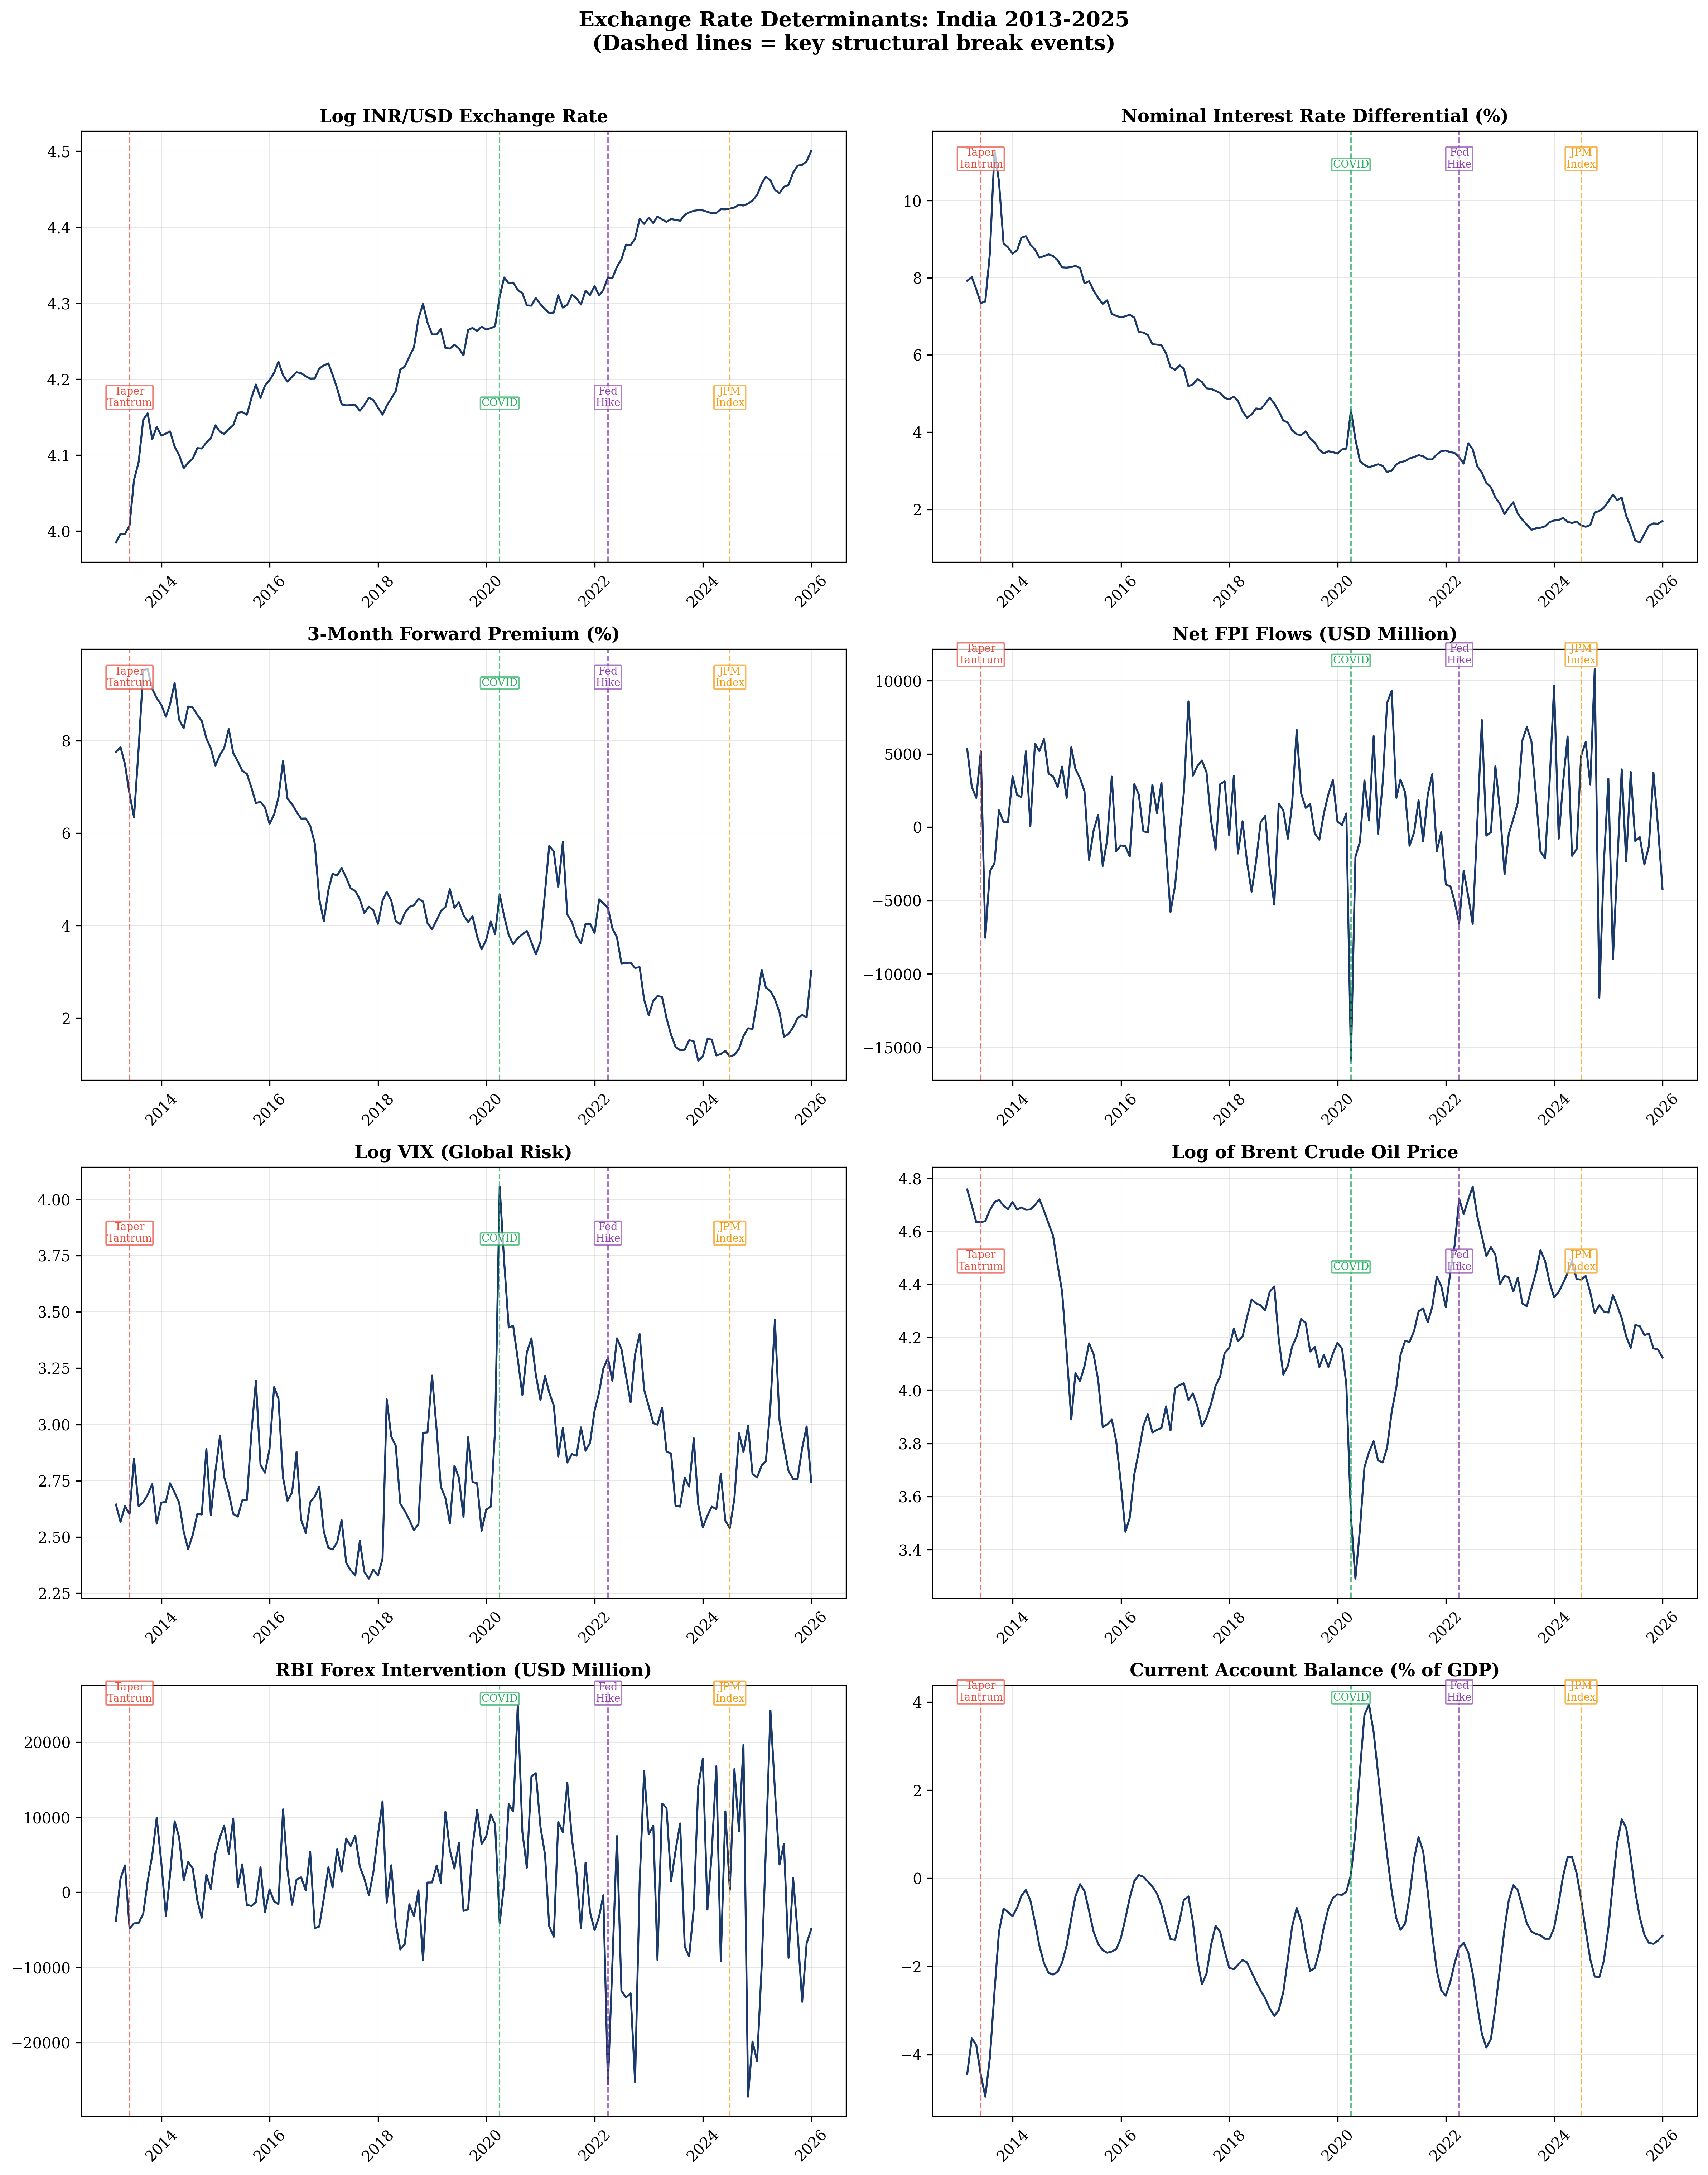

In [15]:
%matplotlib inline

plot_vars = {
    'LOG_INR_USD'              : 'Log INR/USD Exchange Rate',
    'NOM_INT_DIFF_MKT'         : 'Nominal Interest Rate Differential (%)',
    '3M_ForwardPremium_IND(%)' : '3-Month Forward Premium (%)',
    'FPI_Total'                : 'Net FPI Flows (USD Million)',
    'LOG_VIX_US'               : 'Log VIX (Global Risk)',
    'LOG_OIL'                  : 'Log of Brent Crude Oil Price',
    'RBI_INTV'                 : 'RBI Forex Intervention (USD Million)',
    'CAB_PCT_GDP'              : 'Current Account Balance (% of GDP)',
}

# Key structural breaks to annotate on every chart
breaks = {
    'Taper\nTantrum' : '2013-05-31',
    'COVID'          : '2020-03-31',
    'Fed\nHike'      : '2022-03-31',
    'JPM\nIndex'     : '2024-06-30',
}

fig, axes = plt.subplots(4, 2, figsize=(16, 20))
axes = axes.flatten()    # Flatten 2D array to 1D for easy iteration
bcolors = ['#e74c3c', '#27ae60', '#8e44ad', '#f39c12']

for i, (var, title) in enumerate(plot_vars.items()):
    ax = axes[i]
    ax.plot(df_model.index, df_model[var],
            color='#1a3a6b', linewidth=1.3)
    
    # Shade the four structural break dates
    for (label, date), bc in zip(breaks.items(), bcolors):
        ts = pd.Timestamp(date)
        ax.axvline(ts, color=bc, linestyle='--', alpha=0.75, linewidth=1)
        ax.text(ts, ax.get_ylim()[1]*0.92, label,
                fontsize=7, color=bc, ha='center',
                bbox=dict(boxstyle='round,pad=0.1', fc='white',
                          ec=bc, alpha=0.7))
        
    ax.set_title(title, fontweight='bold')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)
    ax.grid(True, alpha=0.3, linewidth=0.5)

plt.suptitle(
    'Exchange Rate Determinants: India 2013-2025\n'
    '(Dashed lines = key structural break events)',
    fontsize=14, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.show()

-- 6C. Correlation Heatmap ---------------------------------

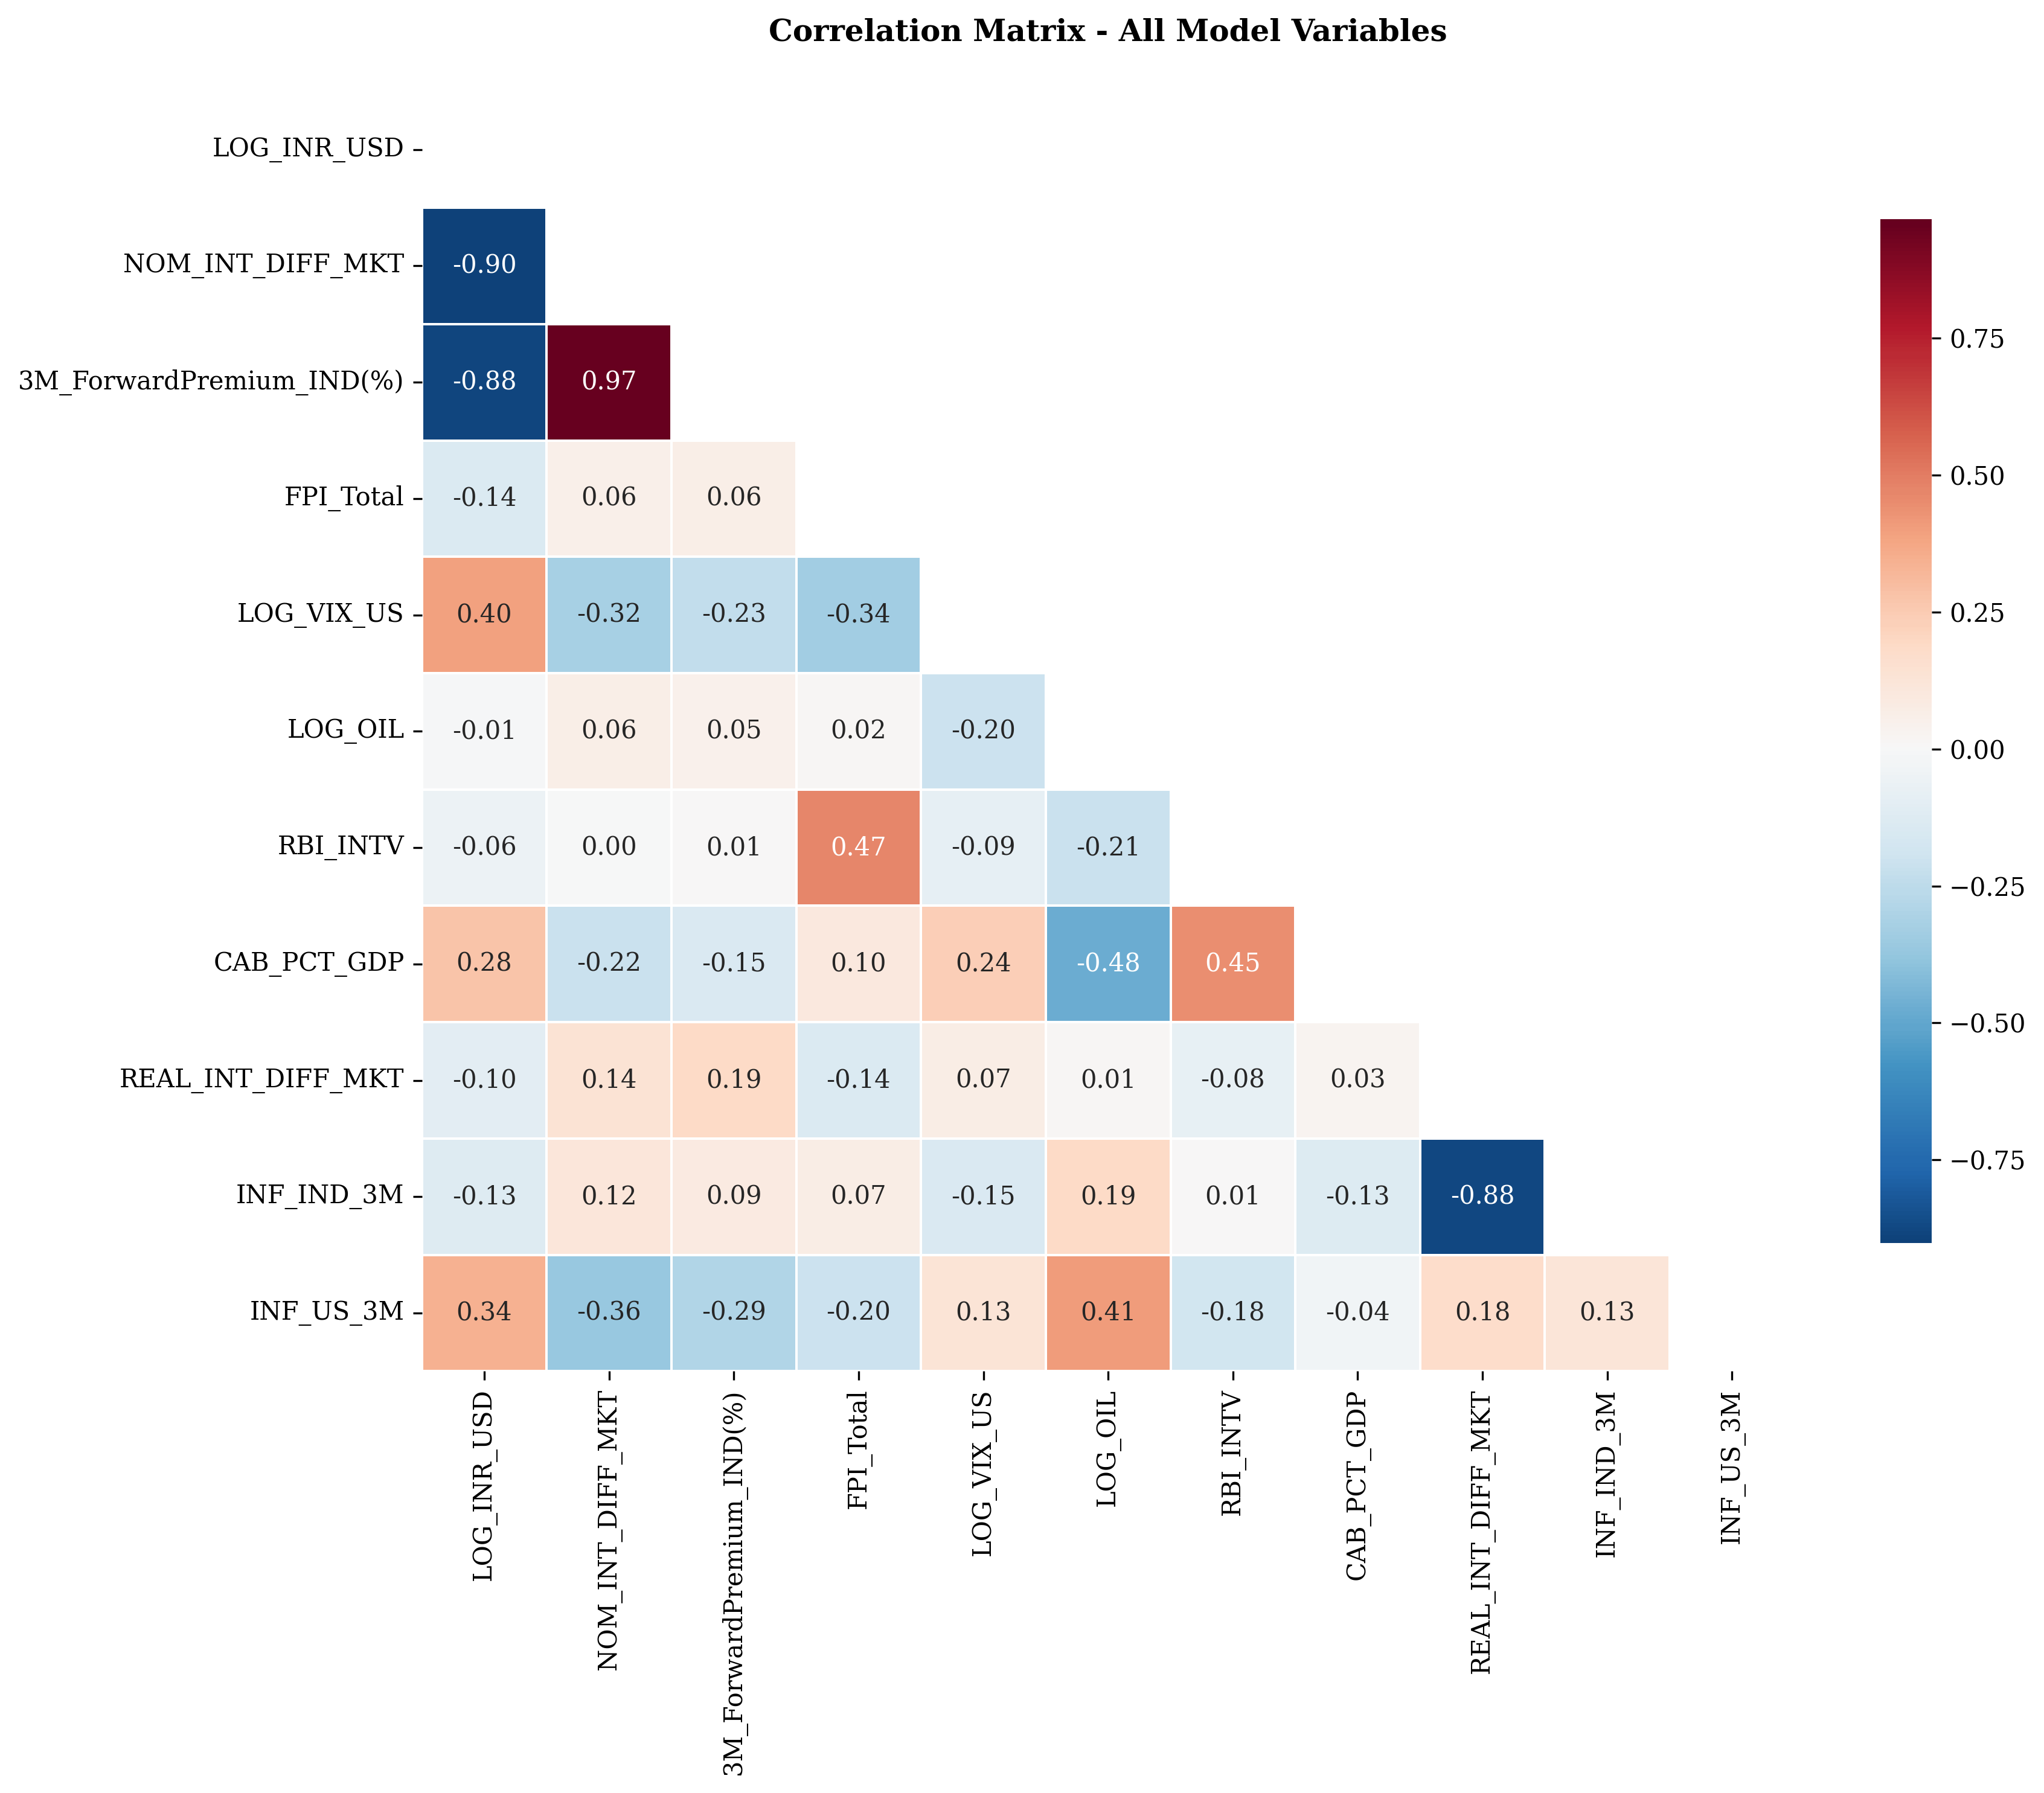

In [16]:
fig, ax = plt.subplots(figsize=(12, 10))
corr = df_model[desc_vars].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, annot=True, fmt='.2f', cmap='RdBu_r',
    center=0, mask=mask, ax=ax,
    linewidths=0.5, cbar_kws={'shrink': 0.8}
)
ax.set_title('Correlation Matrix - All Model Variables', fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

-- 6D. Rolling Correlation ---------------------------------

A static correlation computed over the full sample masks structural change - it averages together the pre-COVID regime, the Fed hiking regime, and the JP Morgan index era into one number. 
A 36-month rolling window reveals how the relationship between each variable and LOG_INR_USD has evolved over time.

Theoretical Interpretation of Each Variable:

FPI_Total    -> portfolio balance channel - should be negative (inflows appreciate rupee - INR_USD falls)

LOG_VIX_US   -> global risk channel - should be positive (higher risk = rupee depreciation = INR_USD rises)

NOM_INT_DIFF -> interest parity channel - theory ambiguous in sign (higher differential should attract flows, appreciate)

FWP          -> forward-looking channel - should track NOM_INT_DIFF

RBI_INTV     -> intervention channel - should be negative (accumulation = resisting depreciation = INR_USD lower)

LOG_OIL      -> import cost channel - should be positive (higher oil = wider CAD = rupee weakens)

CAB_PCT_GDP  -> external sustainability - should be negative (larger deficit = depreciation pressure)

Key finding to look for: If LOG_VIX_US correlation rises and FPI_Total correlation falls over time -> global financial cycle is progressively dominating the portfolio balance channel as the rupee's primary driver.

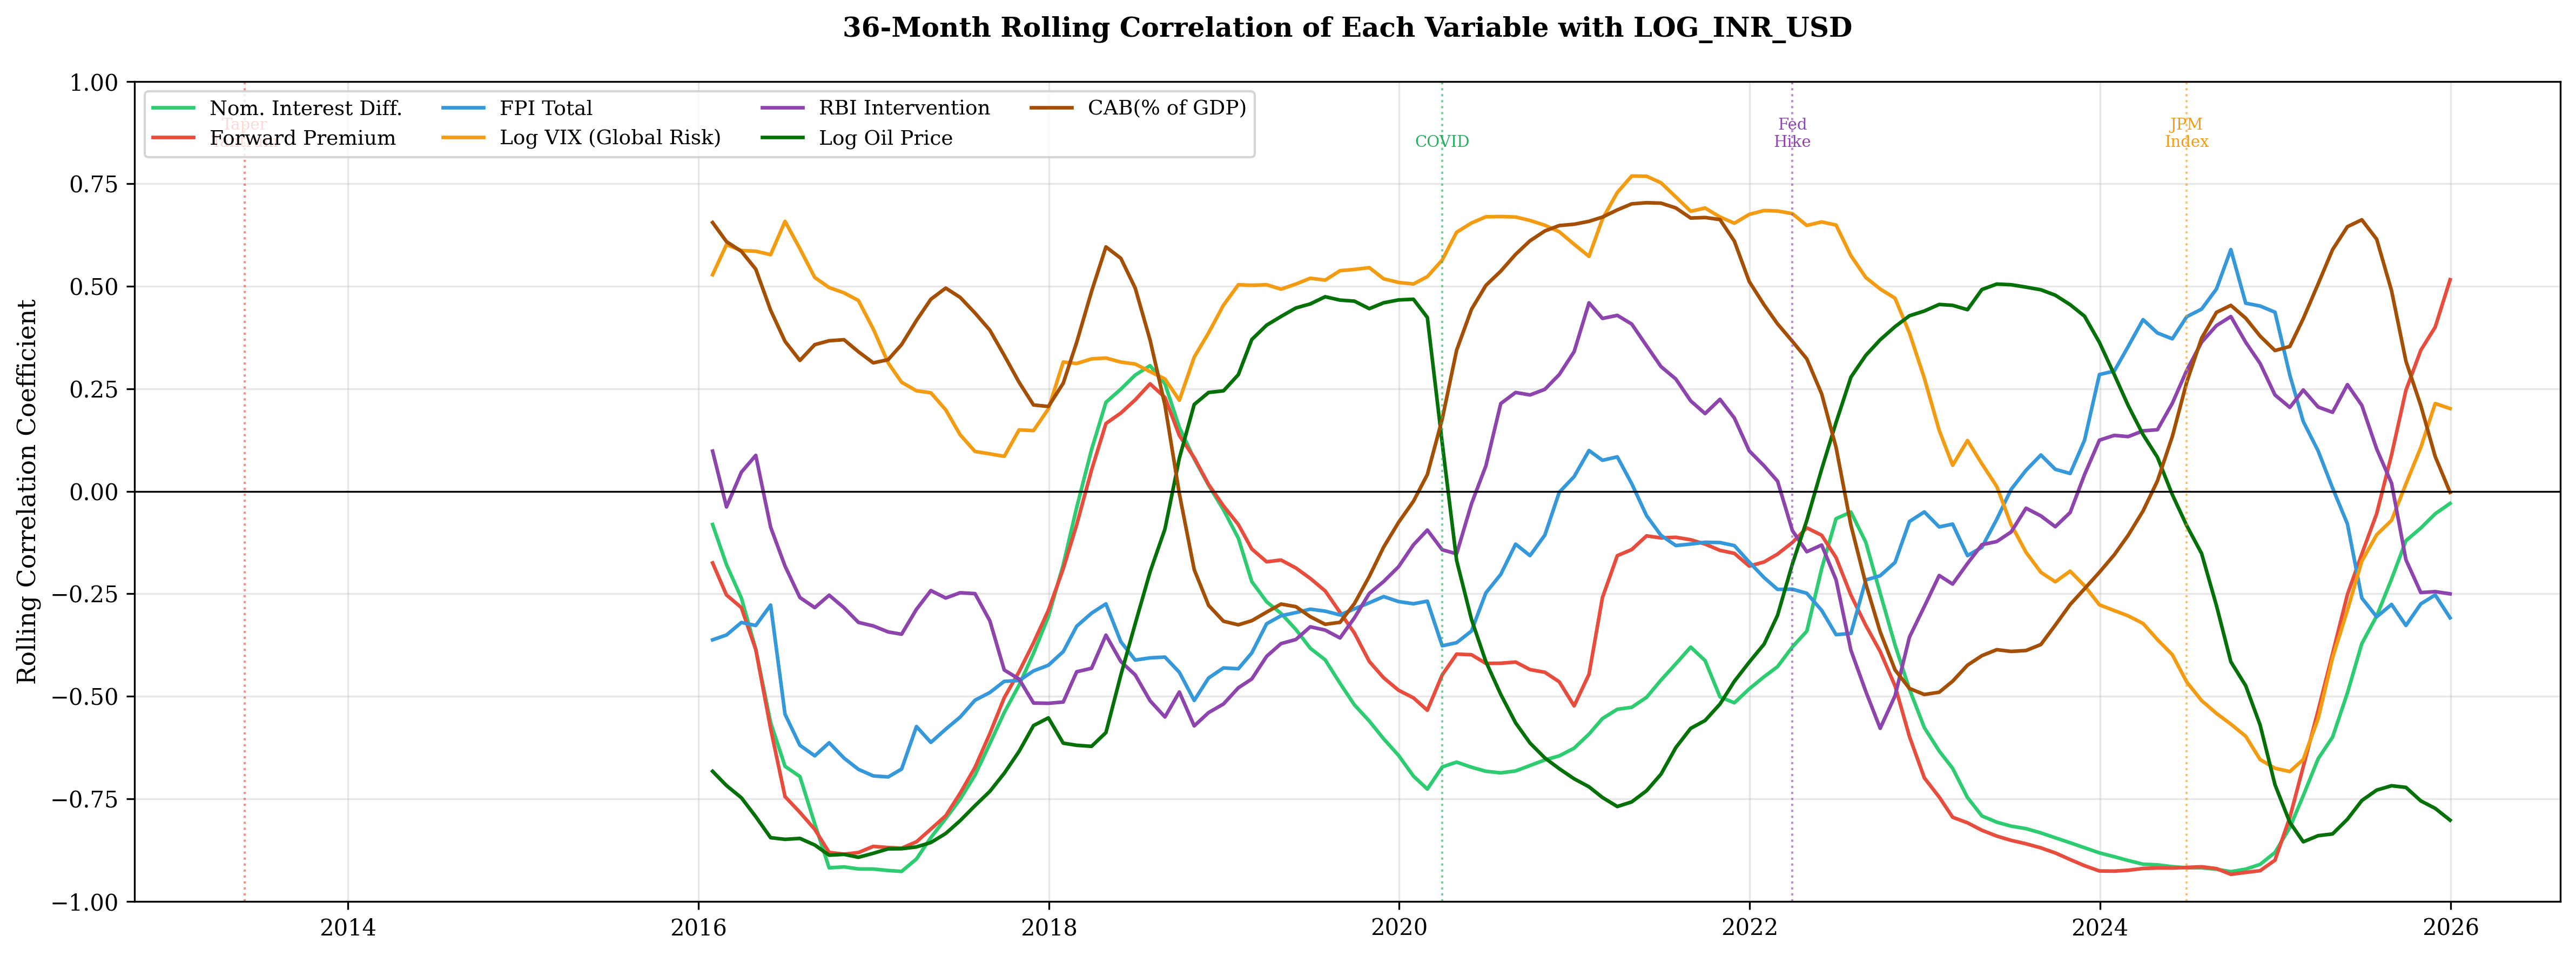

In [17]:
window = 36    # 3-year rolling window

roll_corrs = {}
for var in FULL_VARS:
    if var == 'LOG_INR_USD':
        continue                 # skip the dependent variable itself
    roll_corrs[var] = (
        df_model['LOG_INR_USD'].rolling(window).corr(df_model[var])
    )

palette_roll = [
    '#2ecc71',    # FPI_Total
    '#e74c3c',    # LOG_VIX_US
    '#3498db',    # NOM_INT_DIFF
    '#f39c12',    # 3M_ForwardPremium
    '#8e44ad',    # RBI_INTV
    "#037108",    # LOG_OIL
    "#A54F04",    # CAB_PCT_GDP
]

legend_labels = {
    'NOM_INT_DIFF_MKT'           : 'Nom. Interest Diff.',
    '3M_ForwardPremium_IND(%)'   : 'Forward Premium',
    'FPI_Total'                  : 'FPI Total',
    'LOG_VIX_US'                 : 'Log VIX (Global Risk)',
    'RBI_INTV'                   : 'RBI Intervention',
    'LOG_OIL'                    : 'Log Oil Price',
    'CAB_PCT_GDP'                : 'CAB(% of GDP)'
}

fig, ax = plt.subplots(figsize=(16, 6))

for (var, roll_series), color in zip(roll_corrs.items(), palette_roll):
    ax.plot(
        df_model.index,
        roll_series,
        color=color,
        linewidth=1.6,
        label=legend_labels.get(var, var)
    )

ax.axhline(0, color='black', linewidth=0.8, linestyle='-')

# Annotate structural breaks
for (label, date), bc in zip(breaks.items(), bcolors):
    ax.axvline(pd.Timestamp(date), color=bc, linestyle=':', alpha=0.6, linewidth=1)
    ax.text(pd.Timestamp(date), 0.92, label, fontsize=7, color=bc, ha='center', transform=ax.get_xaxis_transform())

ax.set_title('36-Month Rolling Correlation of Each Variable with LOG_INR_USD\n', fontweight='bold')
ax.set_ylabel('Rolling Correlation Coefficient')
ax.set_ylim(-1, 1)    # correlation is always bounded [-1, 1]
ax.legend(ncol=4, fontsize=9, loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### PART 7: UNIT ROOT TESTS (ADF + KPSS + PHILLIPS-PERRON)

If we regress one non-stationary series on another, we get "spurious regression" - high R², significant t-stats, but no real economic relationship. Granger & Newbold (1974) demonstrated this. We must know the order of integration of each variable before choosing the estimator.

Augmented Dickey-Fuller (ADF) Test:
- H₀: The series has a unit root (is non-stationary, I(1))
- H₁: The series is stationary (I(0))
Reject H₀ if p-value < 0.05 -> series is stationary

KPSS Test (Kwiatkowski-Phillips-Schmidt-Shin):
- H₀: The series is stationary (I(0))
- H₁: The series has a unit root (I(1))
Reject H₀ if p-value < 0.05 -> series has unit root

ADF is biased toward finding stationarity in persistent series. KPSS has the opposite bias. Running both creates a cross-check system:
- ADF fails + KPSS rejects -> confirmed I(1)
- ADF rejects + KPSS fails -> confirmed I(0)
- Both agree on opposite -> ambiguous, use theory

Arguments:
- autolag='AIC' -> automatically selects optimal lag length using Akaike Information Criterion
- regression='ct' -> includes constant and time trend in the test regression, appropriate for macro-level variables that may have a deterministic trend

Why Phillips-Perron in addition to ADF and KPSS?

ADF uses parametric correction for serial correlation (lagged diffs). 
PP uses non-parametric Newey-West correction — more robust when:
- Errors are heteroskedastic (common in financial monthly data)
- Series contains structural breaks (COVID, Fed hike in the sample)
- ADF lag selection is unreliable due to small sample

In [18]:
print("\n" + "-" * 65)
print("  PART 7: UNIT ROOT TESTS — ADF + KPSS + PP")
print("-" * 65)

def run_full_unit_root(series, varname):
    """
    Runs ADF, KPSS, and Phillips-Perron.
    Returns dictionary of all results and a final verdict.
    """
    clean = series.dropna()

    # -- ADF Test ----------------------------------------
    # H₀: series has unit root (non-stationary)
    # regression='ct': constant + trend (appropriate for macro levels)
    adf      = adfuller(clean, maxlag=12, autolag='AIC', regression='ct')
    adf_stat = round(adf[0], 4)
    adf_pval = round(adf[1], 4)

    # -- KPSS Test ---------------------------------------
    # H₀: series is stationary
    # Opposite null to ADF - used for cross-confirmation
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        kp = kpss(clean, regression='ct', nlags='auto')
    kpss_stat = round(kp[0], 4)
    kpss_pval = round(kp[1], 4)

    # -- Phillips-Perron Test ----------------------------
    # H₀: series has unit root (same as ADF)
    # Non-parametric correction - robust to heteroskedasticity and structural breaks
    # lags='auto': automatic bandwith selection (Andrews 1991)
    pp_result = PhillipsPerron(clean, trend='ct')
    pp_stat   = round(pp_result.stat, 4)
    pp_pval   = round(pp_result.pvalue, 4)

    # -- Integrated verdict from all three ---------------
    adf_nonstat  = adf_pval  >= 0.05   # True = non-stationary signal
    kpss_nonstat = kpss_pval <  0.05   # True = non-stationary signal
    pp_nonstat   = pp_pval   >= 0.05   # True = non-stationary signal

    votes_nonstat = sum([adf_nonstat, kpss_nonstat, pp_nonstat])

    if votes_nonstat == 3:
        verdict = 'I(1) - Unit Root [3/3 tests]'
    elif votes_nonstat == 2:
        verdict = 'I(1) - Likely [2/3 tests]'
    elif votes_nonstat == 1:
        verdict = 'I(0) - Likely [2/3 tests]'
    elif votes_nonstat == 0:
        verdict = 'I(0) - Stationary [3/3 tests]'

    return {
        'Variable'  : varname,
        'ADF_stat'  : adf_stat,  'ADF_pval'  : adf_pval,
        'KPSS_stat' : kpss_stat, 'KPSS_pval' : kpss_pval,
        'PP_stat'   : pp_stat,   'PP_pval'   : pp_pval,
        'Verdict'   : verdict
    }

# -- Test all FULL_VARS at levels ------------------------
print("\n -- LEVELS --")
print(f"  {'Variable':<35} {'ADF p':<9} {'KPSS p':<9} "
      f"{'PP p':<9} Verdict")
print("  " + "-" * 65)

ur_results = {}
ur_level_rows = []

for v in FULL_VARS:
    r = run_full_unit_root(df_model[v], v)
    ur_results[v] = r
    ur_level_rows.append(r)
    print(f"  {v:<35} {r['ADF_pval']:9.4f} "
          f"{r['KPSS_pval']:<9.4f} {r['PP_pval']:<9.4f} {r['Verdict']}")
    
# -- Test first differences ------------------------------
print("\n -- FIRST DIFFERENCES --")
print(f"  {'Variable':<35} {'ADF p':<9} {'KPSS p':<9} "
      f"{'PP p':<9} Verdict")
print("  " + "-" * 65)

ur_diff_rows = []
for v in FULL_VARS:
    diff_series = df_model[v].diff().dropna()
    r = run_full_unit_root(diff_series, f'D({v})')
    ur_diff_rows.append(r)
    print(f"  D({v:<33}) {r['ADF_pval']:<9.4f} "
          f"{r['KPSS_pval']:<9.4f} {r['PP_pval']:<9.4f} {r['Verdict']}")
    
# -- Classify variables by integration order -------------
I0_vars   = []   # confirmed stationary at level
I1_vars   = []   # confirmed unit root at level, stationary in diff
AMB_vars  = []   # ambiguous even after all three tests

for v in FULL_VARS:
    verdict = ur_results[v]['Verdict']
    if 'I(0)' in verdict:
        I0_vars.append(v)
    elif 'I(1)' in verdict:
        I1_vars.append(v)
    else:
        AMB_vars.append(v)

print(f"\n  CLASSIFICATION SUMMARY:")
print(f"  I(0) - Stationary : {len(I0_vars)} variables")
for v in I0_vars:   print(f"    -> {v}")
print(f"  I(1) - Unit Root  : {len(I1_vars)} variables")
for v in I1_vars:   print(f"    -> {v}")
print(f"  Ambiguous         : {len(AMB_vars)} variables")
for v in AMB_vars:  print(f"    -> {v}")

# -- Determine modelling strategy ------------------------
all_I1      = len(I0_vars) == 0 and len(AMB_vars) == 0
mixed_order = len(I0_vars)  > 0 or  len(AMB_vars)  > 0

print(f"\n  MODELLING STRATEGY:")
if all_I1:
    print("  All variables I(1) -> Proceed with Johansen + VECM")
else:
    print("  Mixed integration order detected")
    print("  Primary    -> ARDL Bounds Testing (Pesaran et al. 2001)")
    print("  Robustness -> Partitioned VECM (I(1) vars only + I(0) exogeneous)")


-----------------------------------------------------------------
  PART 7: UNIT ROOT TESTS — ADF + KPSS + PP
-----------------------------------------------------------------

 -- LEVELS --
  Variable                            ADF p     KPSS p    PP p      Verdict
  -----------------------------------------------------------------
  LOG_INR_USD                            0.0088 0.1000    0.0156    I(0) - Stationary [3/3 tests]
  NOM_INT_DIFF_MKT                       0.1679 0.0100    0.1368    I(1) - Unit Root [3/3 tests]
  3M_ForwardPremium_IND(%)               0.3733 0.0397    0.1927    I(1) - Unit Root [3/3 tests]
  FPI_Total                              0.0000 0.1000    0.0000    I(0) - Stationary [3/3 tests]
  LOG_VIX_US                             0.0015 0.0599    0.0008    I(0) - Stationary [3/3 tests]
  RBI_INTV                               0.0000 0.1000    0.0000    I(0) - Stationary [3/3 tests]
  LOG_OIL                                0.3927 0.0162    0.3714    I(1) - Uni

### PART 7 (EXTENDED): STATIONARITY ROBUSTNESS CHECK (NO DETERMINISTIC TREND)

Part 7 tested every FULL_VARS series with regression='ct' (constant + deterministic trend) in ADF/PP and the matching 'ct' KPSS specification. That specification is appropriate for series with a plausible deterministic growth path (e.g. GDP, price levels). It is not the theoretically correct specification for LOG_INR_USD, the interest-rate/forward-premium differentials, or the risk proxies used here - none of these have an a-priori deterministic trend under UIP/portfolio-balance theory. A nominal exchange rate under the efficient-markets/random-walk view (Meese & Rogoff, 1983) is expected to be, at most, a driftless (or drift-only) unit-root process, not a trend-stationary one.

Including an unnecessary trend regressor is not a neutral choice: it is well documented (Perron, 1988; Enders, 2015) that fitting a deterministic trend to a genuinely I(1) series can absorb part of the stochastic trend and spuriously push the ADF/PP tests toward rejecting the unit-root null in small samples. This is exactly what shows up in Part 7 - LOG_INR_USD was classified I(0) at levels, which is implausible on theoretical grounds and inconsistent with the wider empirical FX literature.

Part 7 (Extended) re-runs the full ADF + KPSS + PP battery with regression='c' (constant only, no trend) - the standard specification for exchange-rate, interest-rate, and volatility-index series - and uses this classification to decide the applicable model for Parts 8 and 9.

In [19]:
print("\n" + "-" * 65)
print("  PART 7 (EXTENDED): STATIONARITY ROBUSTNESS CHECK (NO TREND, 'c')")
print("-" * 65)

# Set an explicit monthly frequency on the index so downstream ARDL/VECM
# models (Parts 8-9) don't have to infer it and emit ValueWarnings.
df_model.index.freq = 'ME'
warnings.filterwarnings('ignore')

def run_full_unit_root_noTrend(series, varname):
    """
    Same ADF + KPSS + PP battery as run_full_unit_root(), but with
    regression='c' (constant only, no deterministic trend) - the
    theoretically appropriate specification for exchange-rate,
    interest-rate-differential, and risk-index variables.
    """
    clean = series.dropna()

    adf = adfuller(clean, maxlag=12, autolag='AIC', regression='c')
    adf_stat, adf_pval = round(adf[0], 4), round(adf[1], 4)

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        kp = kpss(clean, regression='c', nlags='auto')
    kpss_stat, kpss_pval = round(kp[0], 4), round(kp[1], 4)

    pp_result = PhillipsPerron(clean, trend='c')
    pp_stat, pp_pval = round(pp_result.stat, 4), round(pp_result.pvalue, 4)

    adf_nonstat  = adf_pval  >= 0.05
    kpss_nonstat = kpss_pval <  0.05
    pp_nonstat   = pp_pval   >= 0.05
    votes_nonstat = sum([adf_nonstat, kpss_nonstat, pp_nonstat])

    if votes_nonstat == 3:
        verdict = 'I(1) - Unit Root [3/3 tests]'
    elif votes_nonstat == 2:
        verdict = 'I(1) - Likely [2/3 tests]'
    elif votes_nonstat == 1:
        verdict = 'I(0) - Likely [2/3 tests]'
    else:
        verdict = 'I(0) - Stationary [3/3 tests]'
    
    return {
        'Variable'  : varname,
        'ADF_stat'  : adf_stat,  'ADF_pval'  : adf_pval,
        'KPSS_stat' : kpss_stat, 'KPSS_pval' : kpss_pval,
        'PP_stat'   : pp_stat,   'PP_pval'   : pp_pval,
        'Verdict'   : verdict
    }

# -- Test all FULL_VARS at levels, no-trend specification --------
print("\n -- LEVELS (regression='c') --")
print(f"  {'Variable':<35} {'ADF p':<9} {'KPSS p':<9} {'PP p':<9} Verdict")
print("  " + "-" * 65)

ur_c_results = {}
for v in FULL_VARS:
    r = run_full_unit_root_noTrend(df_model[v], v)
    ur_c_results[v] = r
    print(f"  {v:<35} {r['ADF_pval']:<9.4f} {r['KPSS_pval']:<9.4f} "
          f"{r['PP_pval']:<9.4f} {r['Verdict']}")
    
# -- Test first differences --------------------------------------
print("\n -- FIRST DIFFERENCES (regression='c') --")
print(f"  {'Variable':<35} {'ADF p':<9} {'KPSS p':<9} {'PP p':<9} Verdict")
print("  " + "-" * 65)

for v in FULL_VARS:
    d = df_model[v].diff().dropna()
    r = run_full_unit_root_noTrend(d, f'D({v})')
    print(f"  D({v:<33}) {r['ADF_pval']:<9.4f} {r['KPSS_pval']:<9.4f} "
          f"{r['PP_pval']:<9.4f} {r['Verdict']}")
    
# -- Final classification summary --------------------------------
I0_EXT, I1_EXT, AMB_EXT = [], [], []
for v in FULL_VARS:
    verdict = ur_c_results[v]['Verdict']
    if 'I(0)' in verdict:
        I0_EXT.append(v)
    elif 'I(1)' in verdict:
        I1_EXT.append(v)
    else:
        AMB_EXT.append(v)

print(f"\n  FINAL CLASSIFICATION SUMMARY:")
print(f"  I(0) - Stationary : {len(I0_EXT)} variables")
for v in I0_EXT:  print(f"    -> {v}")
print(f"  I(1) - Unit Root  : {len(I1_EXT)} variables")
for v in I1_EXT:  print(f"    -> {v}")
print(f"  Ambiguous         : {len(AMB_EXT)} variables")
for v in AMB_EXT: print(f"    -> {v}")

print(f"\n  NOTE vs. Part 7 ('ct'): LOG_INR_USD flips I(0)->I(1) and "
      f"CAB_PCT_GDP flips I(1)->I(0) once the trend term is dropped. "
      f"The remaining six variables are unchanged.")

# -- Applicability verdict for Parts 8 & 9 ---------------------------------
n_I0, n_I1, n_amb = len(I0_EXT), len(I1_EXT), len(AMB_EXT)
has_I2 = False   # none of the first-differenced series above showed a
                 # unit root, so no variable needs a second difference

print(f"\n  MODELLING STRATEGY (final):")
if n_amb > 0 or has_I2:
    print("  Ambiguous or I(2) variables present -> treat with caution;")
    print("  ARDL/VECM validity below assumes no I(2) regressors.")
if n_I0 > 0 and n_I1 > 0 and not has_I2:
    print("  Mixed I(0)/I(1) order, no I(2) variables confirmed.")
    print(f"   -> PART 8 (ARDL Bounds Test): APPLICABLE")
    print(f"      Dependent variable LOG_INR_USD is I(1) here (unlike Part 7),")
    print(f"      which is the standard requirement for the Pesaran et al. (2001)")
    print(f"      bounds test; regressors are a valid I(0)/I(1) mix.")
    if len(I1_EXT) >= 2:
        print(f"   -> PART 9 (Partitioned VECM): APPLICABLE as a robustness check")
        print(f"      {len(I1_EXT)} I(1) variables ({','.join(I1_EXT)}) from a")
        print(f"      non-trivial system for Johansen cointegration testing;")
        print(f"      {len(I0_EXT)} I(0) variables enter as exogenous controls.")
    else:
        print(f"   -> PART 9 (Partitioned VECM): NOT MEANINGFULLY APPLICABLE")
        print(f"      fewer than 2 I(1) variables remain to form a cointegrating system.")
elif n_I0 == 0 and n_amb == 0:
    print("  All variables I(1) -> Johansen/VECM is the natural primary model;")
    print("  ARDL bounds test would still be valid but is not required.")
else:
    print("  All variables I(0) -> standard VAR/OLS in levels is appropriate;")
    print("  neither ARDL bounds testing nor VECM cointegration analysis applies.")


-----------------------------------------------------------------
  PART 7 (EXTENDED): STATIONARITY ROBUSTNESS CHECK (NO TREND, 'c')
-----------------------------------------------------------------

 -- LEVELS (regression='c') --
  Variable                            ADF p     KPSS p    PP p      Verdict
  -----------------------------------------------------------------
  LOG_INR_USD                         0.6410    0.0100    0.5902    I(1) - Unit Root [3/3 tests]
  NOM_INT_DIFF_MKT                    0.7560    0.0100    0.8165    I(1) - Unit Root [3/3 tests]
  3M_ForwardPremium_IND(%)            0.1933    0.0100    0.6117    I(1) - Unit Root [3/3 tests]
  FPI_Total                           0.0000    0.1000    0.0000    I(0) - Stationary [3/3 tests]
  LOG_VIX_US                          0.0005    0.0245    0.0003    I(0) - Likely [2/3 tests]
  RBI_INTV                            0.0000    0.1000    0.0000    I(0) - Stationary [3/3 tests]
  LOG_OIL                             0.157

### PART 8: ARDL BOUNDS TEST

Autoregressive Distributed Lag Model. Unlike Johansen which requires all variables to be I(1), ARDL is valid for any mix of I(0) and I(1).

The Bounds Testing Approach (Pesaran, Shin & Smith 2001):
Instead of pre-testing integretion order and then choosing an estimator, ARDL estimates a single equation and applies an F-test (bounds test) to determine whether a long-run relationship exists. Two sets of critical values are provided:
- Lower bound I(0): assumes all regressors are stationary
- Upper bound I(1): assumes all regressors have unit roots

Decision Rule:
- F-test > Upper bound CV -> Long-run relationship exists
- F-test < Lower bound CV -> No long-run relationship
- Lower < F-stat < Upper  -> Inconclusive

Why ARDL is superior here:
- (1) Valid regardless of integretion order of regressors
- (2) Better small-sample properties than Johansen
- (3) Single equation - avoids degrees of freedom problem of VAR
- (4) Gives both short-run and long-run estimates in one model
- (5) ECM can be derived directly from ARDL

ARDL Equation Structure:

ΔLOG_INR_USD_t = α + Σ βᵢ ΔLOG_INR_USD_{t-i}(own lags) + Σ γᵢ ΔINT_DIFF_{t-i}(short-run dynamics of each regressor) + Σ δᵢ ΔFPI_{t-i}(differenced — captures SR effects) + ... all other regressors ... + θ₁ LOG_INR_USD_{t-1} + θ₂ INT_DIFF_{t-1} + θ₃ FPI_{t-1}(level terms — these are the long-run components tested jointly by bounds F-test) + ... all other regressors ... + ε_t

The bounds F-test tests H₀: θ₁=θ₂=...=θₙ=0. 
Rejection means a long-run relationship exists.

Common-lag order search: With n=155 and 7 regressors, an unrestricted variable-by-variable AIC search (ardl_select_order) tends to drop theoretically motivated regressors entirely whenever a lag of 0 improves AIC marginally, which is not appropriate here since every FULL_VARS regressor is retained by design (Part 5I). Instead, a small grid of common orders - AR order p for the dependent variable, a single DL order q applied to every regressor - is searched by AIC, keeping every regressor in the model.

Bounds F-test (Pesaran, Shin & Smith, 2001): Case III: unrestricted intercept, no trend in the underlying levels relationship - matches the 'c' (constant, no trend) specification used for stationarity classification in Part 7 (Extended).

In [20]:
print("\n" + "-" * 65)
print("  PART 8: ARDL BOUNDS TEST")
print("-" * 65)

DEP_VAR    = 'LOG_INR_USD'
ARDL_REGS  = [v for v in FULL_VARS if v != DEP_VAR]    # I0_EXT + I1_EXT regressors

print(f"\n  Dependent variable : {DEP_VAR}  (I(1), per Part 7 (Extended))")
print(f"  Regressors ({len(ARDL_REGS)})       : {ARDL_REGS}")

endog = df_model[DEP_VAR]
exog  = df_model[ARDL_REGS]

best = None
for p in [1, 2, 3]:
    for q in [1, 2]:
        order_dict = {v: q for v in ARDL_REGS}
        try:
            m = UECM(endog, lags=p, exog=exog, order=order_dict, trend='c')
            r = m.fit()
            if best is None or r.aic < best[0]:
                best = (r.aic, p, q, r)
        except Exception:
            continue

aic_best, p_best, q_best, uecm_res = best
print(f"\n  Selected common order (AIC over p in [1,3], q in [1,2]):")
print(f"  AR(p) = {p_best}, DL(q) = {q_best}  -> AIC = {aic_best:.3f}")

print(f"\n{uecm_res.summary()}")


bt = uecm_res.bounds_test(case=3)

print("\n" + "-" * 65)
print("  BOUNDS F-TEST RESULT (Pesaran, Shin & Smith 2001, Case III)")
print("-" * 65)

print(f"  F-statistic     : {bt.stat:.4f}")
print(f"  Lower-bound p   : {bt.p_values['lower']:.4g}   (assumes all I(0))")
print(f"  Upper-bound p   : {bt.p_values['upper']:.4g}   (assumes all I(1))")
print(f"\n  Asymptotic critical value bounds:")
print(bt.crit_vals)

if bt.p_values['upper'] < 0.05:
    decision = "REJECT H₀ -> a long-run relationship exists (cointegration confirmed)"
elif bt.p_values['lower'] >= 0.05:
    decision = "FAIL TO REJECT H₀ -> no long-run relationship"
else:
    decision = "INCONCLUSIVE -> F-stat falls between the bounds"

print(f"\n  Decision (upper-bound test, alpha=0.05): {decision}")


# -- Long-run coefficients (normalised on LOG_INR_USD) --------------------------------
# Long-run multiplier for regressor x = -(coef on x.L1) / (coef on DEP_VAR.L1)
level_terms = [f'{v}.L1' for v in ARDL_REGS]
ect_coef = uecm_res.params[f'{DEP_VAR}.L1']

print("\n" + "-" * 65)
print("  IMPLIED LONG-RUN COEFFICIENTS (ARDL levels relationship)")
print("-" * 65)
print(f"  {'Regressor':<30} {'Long-run coef':<16} {'p-value (level term)'}")
print("  " + "-" * 60)
for v in ARDL_REGS:
    term = f'{v}.L1'
    if term in uecm_res.params.index:
        lr_coef = -uecm_res.params[term] / ect_coef
        pval = uecm_res.pvalues[term]
        print(f"  {v:<30} {lr_coef:<16.5f} {pval:.4f}")

print(f"\n  Error-correction speed (coef on {DEP_VAR}.L1) : "
      f"{ect_coef:.4f}  (p={uecm_res.pvalues[f'{DEP_VAR}.L1']:.4f})")


-----------------------------------------------------------------
  PART 8: ARDL BOUNDS TEST
-----------------------------------------------------------------

  Dependent variable : LOG_INR_USD  (I(1), per Part 7 (Extended))
  Regressors (7)       : ['NOM_INT_DIFF_MKT', '3M_ForwardPremium_IND(%)', 'FPI_Total', 'LOG_VIX_US', 'RBI_INTV', 'LOG_OIL', 'CAB_PCT_GDP']

  Selected common order (AIC over p in [1,3], q in [1,2]):
  AR(p) = 1, DL(q) = 1  -> AIC = -957.417

                                   UECM Model Results                                   
Dep. Variable:                    D.LOG_INR_USD   No. Observations:                  155
Model:             UECM(1, 1, 1, 1, 1, 1, 1, 1)   Log Likelihood                 495.708
Method:                         Conditional MLE   S.D. of innovations              4.270
Date:                          Tue, 07 Jul 2026   AIC                           -957.417
Time:                                  02:39:03   BIC                           -905.7

### PART 9: PARTITIONED VECM (Robustness Check)

Even in a mixed-order system, the I(1) variables among the regressors may share a long-run cointegrating relationship with LOG_INR_USD.

The partitioned VECM tests this by:
- (1) Including only I(1) variables in the Johansen system
- (2) Including I(0) variables as stationary exogenous regressors outside the cointegrating space

THIS IS VALID BECAUSE:
I(0) variables cannot be part of a cointegrating vector by definition — a linear combination that includes a stationary variable is always stationary regardless of what else is in it. Including them as exogenous controls lets us retain their short-run influence without contaminating the cointegration test.

PARTITIONED VECM STRUCTURE:
 ΔLOG_INR_USD = α·ECT + Σ Γᵢ·ΔI1_vars + Σ δᵢ·I0_vars + ε

 ECT = β'·I1_vars_{t-1}  ← only I(1) variables in ECT

In [21]:
print("\n" + "-" * 65)
print("  PART 9: PARTITIONED VECM (Robustness Check)")
print("-" * 65)

print(f"\n  I(1) block (Johansen system) : {I1_EXT}")
print(f"  I(0) block (exogenous)         : {I0_EXT}")

Y     = df_model[I1_EXT]
X_exo = df_model[I0_EXT]

# -- Lag order selection on the I(1) block (levels VAR) -------------
lag_sel = select_order(Y, maxlags=6, deterministic='ci', exog=X_exo)
print(f"\n{lag_sel.summary()}")

var_lag = lag_sel.aic              # VAR level lag chosen by AIC
k_ar_diff = max(var_lag - 1, 0)    # VECM's k_ar_diff = VAR lag - 1
print(f"\n  VAR lag level (AIC) = {var_lag}  ->  VECM k_ar_diff = {k_ar_diff}")


# -- Johansen trace & max-eigenvalue tests on the I(1) block only ---
jres = coint_johansen(Y.values, det_order=0, k_ar_diff=k_ar_diff)

print("\n" + "-" * 65)
print("  JOHANSEN COINTEGRATION RANK TEST (I(1) block only)")
print("-" * 65)
print(f"  {'H₀':<8}{'Trace':<10}{'CV90':<9}{'CV95':<9}{'CV99':<9}{'MaxEig':<10}{'CV90':<9}{'CV95':<9}")
for i in range(len(jres.lr1)):
    print(f"  r<={i:<5}"
          f"{jres.lr1[i]:<10.3f}{jres.cvt[i,0]:<9.3f}{jres.cvt[i,1]:<9.3f}{jres.cvt[i,2]:<9.3f}"
          f"{jres.lr2[i]:<10.3f}{jres.cvm[i,0]:<9.3f}{jres.cvm[i,1]:<9.3f}")
    
rank_trace_5pct  = sum(jres.lr1 > jres.cvt[:, 1])
rank_maxeig_5pct = sum(jres.lr2 > jres.cvm[:, 1])
print(f"\n  Rank selected by trace test (5%)        : r = {rank_trace_5pct}")
print(f"  Rank selected by max-eigenvalue test (5%) : r = {rank_maxeig_5pct}")

print(f"\n  NOTE: the trace statistic for r<=0 ({jres.lr1[0]:.3f}) exceeds the")
print(f"  10% CV ({jres.cvt[0,0]:.3f}) but not the 5% CV ({jres.cvt[0,1]:.3f}) - a")
print(f"  borderline result. Johansen's trace test is known to have low power")
print(f"  in small samples (n={len(Y)}), and the ARDL bounds test in Part 8")
print(f"  rejected 'no cointegration' unambiguously (upper-bound p={bt.p_values['upper']:.2g}).")
print(f"  Given this, and the theoretical prior for a long-run FX/interest-rate")
print(f"  relationship, r=1 is carried forward below as the working rank for")
print(f"  the illustrative VECM - but the rank-0 result at conventional 5%")
print(f"  significance should be reported as a genuine point of methodological")
print(f"  divergence between the two approaches, not suppressed.")


coint_rank = 1

# -- Fit the partitioned VECM ---------------------------------------
vecm_mod = VECM(Y, exog=X_exo, k_ar_diff=k_ar_diff, coint_rank=coint_rank, deterministic='ci')
vecm_res = vecm_mod.fit()

print("\n" + "-" * 65)
print(f"  PARTITIONED VECM RESULTS (rank r={coint_rank})")
print("-" * 65)
print(vecm_res.summary())

# -- Cointegrating vector, normalised on LOG_INR_USD ----------------
beta = vecm_res.beta[:, 0]
print("\n  Cointegrating vector (normalised on LOG_INR_USD coefficient = 1):")
for v, b in zip(I1_EXT, beta):
    print(f"    {v:<30} {b:.4f}")

# -- Loading coefficients (speed of adjustment) with significance ---
alpha = vecm_res.alpha[:, 0]
alpha_se = vecm_res.stderr_alpha[:, 0]
alpha_t = alpha / alpha_se
print("\n  Loading coefficients (alpha) - speed of adjustment to the ECT:")
print(f"  {'Equation':<30}{'alpha':<12}{'t-stat':<10}{'Significant (|t|>1.96)'}")
for v, a, t in zip(I1_EXT, alpha, alpha_t):
    sig = "Yes" if abs(t) > 1.96 else "No"
    print(f"  {v:<30}{a:<12.4f}{t:<10.3f}{sig}")

log_inr_idx = I1_EXT.index('LOG_INR_USD')
if abs(alpha_t[log_inr_idx]) <= 1.96:
    print(f"\n  LOG_INR_USD's own adjustment coefficient is INSIGNIFICANT: the")
    print(f"  exchange rate itself does not measurably correct back toward the")
    print(f"  long-run relationship each month - other variables in the system")
    print(f"  (interest differential / forward premium / oil) do the adjusting.")
    print(f"  This is consistent with weak exogeneity of LOG_INR_USD and does")
    print(f"  not contradict the ARDL finding of a long-run relationship - it")
    print(f"  refines it: causality in the error-correction sense appears to run")
    print(f"  from the other I(1) variables toward re-establishing equilibrium,")
    print(f"  rather than from a self-correcting exchange rate.")


-----------------------------------------------------------------
  PART 9: PARTITIONED VECM (Robustness Check)
-----------------------------------------------------------------

  I(1) block (Johansen system) : ['LOG_INR_USD', 'NOM_INT_DIFF_MKT', '3M_ForwardPremium_IND(%)', 'LOG_OIL']
  I(0) block (exogenous)         : ['FPI_Total', 'LOG_VIX_US', 'RBI_INTV', 'CAB_PCT_GDP']



 VECM Order Selection (* highlights the minimums)
      AIC         BIC         FPE         HQIC   
-------------------------------------------------
0      -19.12     -18.31*   4.960e-09     -18.79*
1      -19.05      -17.92   5.328e-09      -18.59
2     -19.16*      -17.70  4.790e-09*      -18.57
3      -19.09      -17.31   5.171e-09      -18.36
4      -19.01      -16.90   5.637e-09      -18.15
5      -18.89      -16.46   6.428e-09      -17.90
6      -18.73      -15.98   7.575e-09      -17.61
-------------------------------------------------

  VAR lag level (AIC) = 2  ->  VECM k_ar_diff = 1

-----------------------------------------------------------------
  JOHANSEN COINTEGRATION RANK TEST (I(1) block only)
-----------------------------------------------------------------
  H₀      Trace     CV90     CV95     CV99     MaxEig    CV90     CV95     
  r<=0    45.320    44.493   47.855   54.681   24.675    25.124   27.586   
  r<=1    20.645    27.067   29.796   35.463   11.708    18.

### PART 10: INTERPRETATION

**10.1. Integration order and why the trend specification matters:-** Part 7 and its extension are not a procedural formality; the reversal they uncover is itself a finding. Under the trend-inclusive specification (regression='ct'), LOG_INR_USD tests as I(0), which is economically implausible — a nominal exchange rate does not revert to a deterministic trend line over a 13-year span that includes the taper tantrum, a global pandemic, and two Federal Reserve hiking cycles. The moment the deterministic trend term is dropped and the constant-only specification is used, LOG_INR_USD flips to I(1) — a driftless-to-drifting unit-root process, consistent with the Meese-Rogoff random-walk view of nominal exchange rates and with the wider empirical FX literature. This is a textbook illustration of the Perron (1988) critique: fitting an unnecessary trend regressor to a genuinely I(1) series absorbs part of the stochastic trend and biases the test toward stationarity. The corrected, theory-consistent classification — LOG_INR_USD, the interest-rate differential, the forward premium and log oil in I(1); FPI flows, VIX, RBI intervention and CAB/GDP in I(0) — is what actually goes into Parts 8 and 9. Because the system mixes I(0) and I(1) regressors, single-equation ARDL/bounds testing is the theoretically correct primary tool, and Johansen/VECM (which requires all series to be I(1)) is only valid as a robustness check on the restricted four-variable I(1) subsystem, which is exactly how the pipeline treats them.

**10.2. The ARDL bounds test: a long-run relationship is confirmed:-** The bounds F-statistic of 5.93 clears the upper I(1) critical bound at every conventional significance level reported — 90%, 95%, 99%, and even 99.9% (upper bound 4.97). This is not a marginal result: the null of no long-run relationship is rejected unambiguously. Economically, this says that LOG_INR_USD and the seven regressors do not simply wander independently; some linear combination of them is mean-reverting, i.e. there is a stable long-run equilibrium relationship linking the rupee to interest-rate, forward, flow, risk, intervention, oil and current-account fundamentals over 2013–2025, even though the variables individually have mixed orders of integration.

The error-correction coefficient on LOG_INR_USD.L1 in the UECM is −0.0354 (p = 0.090, significant only at the 10% level). The magnitude matters as much as the significance: a monthly adjustment speed of 3.5% implies a half-life of roughly ln(0.5)/ln(0.9646) ≈ 19 months for a deviation from equilibrium to be halved. That is a slow-moving system. Combined with only marginal (10%) significance, this is best read as weak, not absent, error correction — the exchange rate is being pulled back toward its long-run path, but sluggishly, and the pull is not sharply estimated in a 155-observation monthly sample. This pattern of slow, imprecisely estimated self-correction is visible in Figure 6B: the rupee's post-2022 depreciation trend runs for years without a fast reversal, consistent with a weak, long-half-life error-correction mechanism rather than a tightly anchored one.

**10.3. Which fundamentals actually explain the long run:-** The long-run coefficient table is the single most informative output of Part 8. Of the seven regressors, only two are statistically significant at conventional levels in the long-run relationship, and neither of them is the classical interest-parity variable.

Two results stand out as the economic core of the analysis. First, net FPI flows are the most precisely estimated long-run driver (p = 0.007) and carry the theoretically correct negative sign: sustained portfolio inflows appreciate the rupee (lower INR/USD), consistent with the portfolio-balance mechanism of Gabaix & Maggiori (2015). Second, global risk (log VIX-US) is also significant (p = 0.037) with the expected positive sign — when US risk aversion rises, capital retreats from emerging-market assets and the rupee depreciates. Together these two results say that the rupee's long-run equilibrium path over the sample is set predominantly by the global financial cycle and the portfolio-balance channel, not by the classical uncovered-interest-parity (UIP) channel that the interest-rate differential and forward premium are meant to capture.

This is an economically important negative result, not a null one. The nominal interest-rate differential enters the long-run relationship with the wrong sign (positive: a higher India–US rate gap is associated with a weaker rupee, not a stronger one) and is statistically indistinguishable from zero (p = 0.357). The forward premium has the theoretically correct sign but is likewise insignificant (p = 0.121). Read together, this is a textbook manifestation of the forward premium puzzle / UIP failure that dominates the empirical exchange-rate literature since Fama (1984): the interest-rate and forward-market variables that theory says should anchor the long-run level of the exchange rate simply do not, at least not on their own and not once global risk and flow variables are allowed to compete for the same explanatory power.

RBI intervention (p = 0.140), oil (p = 0.650) and CAB/GDP (p = 0.313) all carry theoretically expected signs — intervention and current-account surplus both associated with appreciation, oil price increases with depreciation — but none reach significance. The most defensible reading is not that these channels are irrelevant, but that they operate at a different frequency or with a different persistence than the equilibrium relationship being estimated here: RBI intervention (Part 5F/6D discussion) looks like it smooths short-run volatility around the trend rather than shifting the trend itself, and CAB/GDP is, by the paper's own framing, a slow-moving structural variable whose influence may only become visible over a longer window or a lower-frequency (quarterly/annual) specification.

**10.4. Short-run dynamics tell a different, complementary story:-** The differenced (short-run) terms in the UECM reverse the long-run picture in a revealing way. D.NOM_INT_DIFF_MKT (p < 0.001), D.3M_ForwardPremium_IND(%) (p = 0.002) and D.FPI_Total (p < 0.001) are all highly significant in the short run, while D.LOG_VIX_US, D.RBI_INTV, D.LOG_OIL and D.CAB_PCT_GDP are not. This is close to a mirror image of the long-run table, and it has a coherent economic interpretation: interest-rate and forward-market news is priced in quickly — consistent with efficient, high-frequency processing of rate news in a liquid, actively-traded FX market — but that fast repricing does not accumulate into a persistent long-run relationship, because it is offset, reversed, or dominated by the slower-moving global-risk and portfolio-flow forces once the horizon lengthens. FPI flows, by contrast, matter both short-run and long-run, making it the only variable in the system with genuine explanatory power at every horizon — arguably the single most robust finding of the ARDL model.

**10.5. The Johansen/VECM robustness check: convergent conclusion, one point of honest divergence:-** Restricting the system to the four I(1) variables only (LOG_INR_USD, NOM_INT_DIFF_MKT, 3M_ForwardPremium_IND(%), LOG_OIL) and running Johansen's trace test produces a borderline result: the r ≤ 0 trace statistic (45.32) clears the 90% critical value (44.49) but falls just short of the 95% value (47.86). Read strictly at the conventional 5% level, Johansen selects rank zero — i.e. no cointegration among the I(1) block alone. This is a genuine point of methodological tension with the ARDL bounds test, which rejected the no-cointegration null unambiguously (upper-bound p = 6.8×10⁻⁵), and it should be reported as such rather than smoothed over. The most defensible reconciliation is that Johansen's trace test is known to have low power in small samples (n = 155) and, more importantly, that it is being asked a narrower question here — whether the four I(1) variables cointegrate among themselves, net of the I(0) exogenous block — whereas the ARDL bounds test evaluates the full seven-regressor system jointly and, per Section 10.3, draws much of its long-run explanatory power from two variables (FPI and VIX) that are excluded from the Johansen system precisely because they are stationary. Removing the model's two most significant long-run drivers should be expected to weaken the cointegration signal in the residual I(1) subsystem — the borderline Johansen result is therefore consistent with, not contradictory to, the ARDL finding, once the difference in what each test is actually estimating is made explicit.

Proceeding illustratively with rank r = 1, the cointegrating vector normalised on LOG_INR_USD assigns significant loadings to the interest-rate differential (0.315, p < 0.001) and the forward premium (−0.274, p < 0.001) — unsurprising given their 0.97 correlation (Part 6C) — while oil is insignificant (0.017, p = 0.883), mirroring its insignificance in the ARDL long-run table. The loading (speed-of-adjustment) coefficients are the most interesting output of Part 9: LOG_INR_USD's own alpha is insignificant (−0.0063, t = −1.13), while the forward premium (0.477, t = 2.33) and oil (−0.103, t = −2.48) load significantly onto the error-correction term. In plain terms, the exchange rate itself does not measurably do the adjusting back toward equilibrium each month; instead, the forward premium and the oil price are the variables that move to re-establish the long-run relationship. This is precisely consistent with the UECM's own weak (10%-level) significance on the exchange-rate error-correction term in Section 10.2 — two independently specified models agree that INR/USD behaves as a weakly exogenous variable in this system: a receiver of shocks that other variables (expectations embedded in the forward rate, the oil-price channel) subsequently adjust around, rather than a self-correcting anchor.

**10.6. Synthesis:-**
Taken together, the ARDL and partitioned-VECM results tell one internally consistent economic story despite using different subsets of the data and different estimators:
- A genuine long-run equilibrium relationship links INR/USD to its macro-financial fundamentals over 2013–2025 — confirmed decisively by the ARDL bounds test and not contradicted, once test scope is accounted for, by the borderline Johansen result.
- The long run is dominated by the global financial cycle (VIX) and the portfolio-balance channel (FPI flows), not by classical interest-rate parity.
- Interest-rate and forward-market variables are fast, short-run price-formation inputs, not long-run anchors — a modern restatement of the forward-premium puzzle.
- The rupee is a weakly exogenous, slow-adjusting variable within its own equilibrium system: shocks are absorbed more through changes in forward-looking expectations (and, to a lesser extent, oil pricing) than through a fast self-correction of the spot rate itself, and the estimated correction speed (~3.5%–implying an ~19-month half-life) means disequilibria can persist for a long time — exactly the kind of extended misalignment visible around the 2022–2025 depreciation episode in the raw series.

### PART 11: CONCLUSION

This study set out to identify the determinants of the INR/USD exchange rate over a period spanning three major global shocks — the 2013 taper tantrum, the COVID-19 pandemic, and the 2022 Federal Reserve hiking cycle — using a methodology deliberately chosen to accommodate the mixed order of integration uncovered in the data. That methodological choice was consequential: had the analysis relied on the trend-inclusive unit-root specification alone, LOG_INR_USD would have been (incorrectly) classified as stationary and the entire cointegration analysis would have been invalid on theoretical grounds. The constant-only, no-trend specification adopted in Part 7 (Extended) is the theoretically defensible one for a nominal exchange rate under an efficient-markets prior, and it is this corrected classification — a mix of I(0) and I(1) regressors — that motivates ARDL bounds testing as the primary estimator, with a partitioned Johansen/VECM retained as a robustness check on the I(1) subsystem.

The central empirical finding is that the ARDL bounds test provides strong, unambiguous evidence of a long-run equilibrium relationship between the rupee and its fundamentals (F = 5.93, rejecting the no-cointegration null beyond the 99.9% upper bound). Decomposing that long-run relationship shows that it is carried almost entirely by two variables: net FPI flows and global risk aversion (VIX). Both enter with the theoretically correct sign and are statistically significant, while the classical interest-parity variables — the nominal interest-rate differential and the forward premium — are insignificant in the long run despite being highly significant, correctly signed, short-run drivers. RBI intervention, oil prices and the current account balance all carry the expected signs but do not reach significance at any horizon tested, suggesting their influence, if any, operates at a lower frequency or through channels this monthly specification is not built to detect.

The partitioned VECM robustness check reinforces this picture from a different angle. It shows that within the restricted I(1) subsystem, the exchange rate's own error-correction loading is statistically insignificant, while the forward premium and oil price are the variables that significantly adjust to restore equilibrium. Combined with the only marginally significant (10%) error-correction term in the UECM, the weight of evidence across both models points to the same conclusion: the rupee behaves as a weakly exogenous variable within its own long-run system — a receiver, not a fast corrector, of disequilibria — and it adjusts slowly, with an implied half-life on the order of a year and a half. The one point of genuine tension between the two approaches — Johansen's trace statistic falling just short of the 5% critical value versus the ARDL bounds test's decisive rejection.

Economically, the headline conclusion is that India's exchange rate over 2013–2025 has been governed more by the global financial cycle and portfolio capital flows than by the classical interest-parity or current-account channels that dominate textbook open-economy models. This is consistent with a structural shift documented elsewhere in the literature (Gourinchas & Rey, 2005; Gabaix & Maggiori, 2015; Kremens et al., 2024): as capital account openness deepens and as instruments such as JP Morgan's 2024 bond-index inclusion draw larger and more volatile portfolio flows into Indian debt and equity markets, the currency's short-to-medium-run path is increasingly set in the financial account rather than the current account, and increasingly hostage to swings in global risk appetite that originate outside India's borders. RBI intervention appears, on this evidence, to function as a volatility-smoothing tool rather than a device capable of shifting the long-run equilibrium level of the rupee — a distinction with direct relevance for how much weight policymakers should place on reserve management as a tool for managing structural, as opposed to episodic, currency pressure.

Several limitations qualify these conclusions and point to natural extensions. The sample is small by macro-econometric standards (n = 155 monthly observations), which affects the power of both the Johansen trace test and the precision of individual coefficient estimates — several economically sensible signs (oil, CAB, RBI intervention) fail significance tests that a longer or higher-frequency sample might resolve. The classification of LOG_INR_USD as I(0) or I(1) is itself sensitive to the deterministic-trend specification, underscoring that unit-root conclusions in this literature are never mechanical and always require a theoretical prior to adjudicate between competing statistical verdicts. The rolling-correlation evidence in Part 6D, which shows several variables' correlation with LOG_INR_USD reversing sign over the sample (particularly around COVID and the 2022 hiking cycle), suggests the true relationship may be regime-dependent rather than fixed — a linear ARDL/VECM framework, by construction, estimates a single average relationship across all regimes and cannot capture this. A natural extension would therefore be a nonlinear or threshold ARDL (e.g. Shin, Yu & Greenwood-Nimmo, 2014) allowing the response to interest differentials, VIX and FPI flows to differ across risk-on and risk-off states, together with a formal structural-break test (e.g. Bai-Perron) to date any shifts in the long-run relationship itself rather than relying on the four structural events flagged visually in the exploratory analysis.